In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================


import pandas as pd
import numpy as np
from pathlib import Path
DATA_DIR = Path("../data")
import  scipy
from scipy.stats.mstats import winsorize

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import OneHotEncoder

from category_encoders import TargetEncoder

import warnings

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

In [2]:
df = pd.read_csv(
    DATA_DIR / "PublicTablesForCarbonCatalogueDataDescriptor_v30Oct2021(Product Level Data).csv",
    encoding="latin1"
)


In [3]:
df.columns


Index(['*PCF-ID', 'Year of reporting', '*Stage-level CO2e available',
       'Product name (and functional unit)', 'Product detail', 'Company',
       'Country (where company is incorporated)',
       'Company's GICS Industry Group', 'Company's GICS Industry',
       '*Company's sector', 'Product weight (kg)',
       '*Source for product weight',
       'Product's carbon footprint (PCF, kg CO2e)', '*Carbon intensity',
       'Protocol used for PCF', 'Relative change in PCF vs previous',
       'Company-reported reason for change', '*Change reason category',
       '*%Upstream estimated from %Operations',
       '*Upstream CO2e (fraction of total PCF)',
       '*Operations CO2e (fraction of total PCF)',
       '*Downstream CO2e (fraction of total PCF)',
       '*Transport CO2e (fraction of total PCF)',
       '*EndOfLife CO2e (fraction of total PCF)',
       '*Adjustments to raw data (if any)'],
      dtype='str')

In [4]:
# ============================================================
# 3. CREATE ML DATASET
# ============================================================

product_df = df.rename(columns={
    "Year of reporting": "Year",

    "Company": "Company",
    "Country (where company is incorporated)": "Country",
    "Company's GICS Industry": "Industry",

    "Product weight (kg)": "Product_Weight",

    "Protocol used for PCF": "PCF_Protocol",

   "*Stage-level CO2e available":"Stage_Level_CO2e_Available",

    "Product's carbon footprint (PCF, kg CO2e)": "PCF"
})

print("ML dataset shape:", product_df.shape)

display(product_df.head())

df_ml = product_df

ML dataset shape: (866, 25)


,*PCF-ID,Year,Stage_Level_CO2e_Available,Product name (and functional unit),Product detail,Company,Country,Company's GICS Industry Group,Industry,*Company's sector,...,Relative change in PCF vs previous,Company-reported reason for change,*Change reason category,*%Upstream estimated from %Operations,*Upstream CO2e (fraction of total PCF),*Operations CO2e (fraction of total PCF),*Downstream CO2e (fraction of total PCF),*Transport CO2e (fraction of total PCF),*EndOfLife CO2e (fraction of total PCF),*Adjustments to raw data (if any)
0,10056-1-2014,2014,Yes,Frosted Flakes(R) Cereal,"Frosted Flakes(R), 23 oz., Produced in Lancast...",Kellogg Company,USA,"Food, Beverage & Tobacco",Food Products,Food & Beverage,...,(not reported by company),N/a,N/a (no %change reported),No,57.50%,30.00%,12.50%,4.50%,(included in downstream but not reported separ...,Divided stage and total emissions by 1000 (bas...
1,10056-1-2015,2015,Yes,"Frosted Flakes, 23 oz, produced in Lancaster, ...",Cereal,Kellogg Company,USA,Food & Beverage Processing,Not used for 2015 reporting,Food & Beverage,...,(not reported by company),N/a,N/a (no %change reported),No,57.50%,30.00%,12.50%,4.50%,(included in downstream but not reported separ...,Divided stage and total emissions by 1000 (bas...
2,10222-1-2013,2013,Yes,Office Chair,Field not included in 2013 data,KNOLL INC,USA,Capital Goods,Building Products,Comm. equipm. & capital goods,...,(not reported by company),N/a,N/a (no previous data available),Yes,80.63%,17.36%,2.01%,(included in up/downstream but not reported se...,0.00%,"Changed %change to zero, according to field ""c..."
3,10261-1-2017,2017,Yes,Multifunction Printers,bizhub C458,"Konica Minolta, Inc.",Japan,Technology Hardware & Equipment,"Electronic Equipment, Instruments & Components","Computer, IT & telecom",...,(not reported by company),N/a,N/a (no previous data available),No,30.65%,5.51%,63.84%,1.01%,2.76%,NaN
4,10261-2-2017,2017,Yes,Multifunction Printers,bizhub C558,"Konica Minolta, Inc.",Japan,Technology Hardware & Equipment,"Electronic Equipment, Instruments & Components","Computer, IT & telecom",...,(not reported by company),N/a,N/a (no previous data available),No,25.08%,4.51%,70.41%,0.83%,2.26%,NaN


In [5]:
# ============================================================
# 4. CLEAN TARGET
# ============================================================

df_ml["PCF"] = pd.to_numeric(
    df_ml["PCF"],
    errors="coerce"
)

df_ml = df_ml[
    df_ml["PCF"].notna()
].copy()

df_ml = df_ml[
    df_ml["PCF"] >= 0
].copy()

print("Usable rows:", len(df_ml))

print("\nPCF summary:")
display(df_ml["PCF"].describe())

print(
    "\nPCF skewness:",
    df_ml["PCF"].skew()
)

Usable rows: 866

PCF summary:


count    8.660000e+02
mean     1.581525e+04
std      1.813733e+05
min      4.000000e-04
25%      7.000000e+00
50%      1.111000e+02
75%      1.600000e+03
max      3.718044e+06
Name: PCF, dtype: float64


PCF skewness: 17.63189911896261


In [6]:
# ============================================================
# 5. DEFINE FEATURES AND TARGET
# ============================================================

FEATURES = [
    "Year",
    "Company",
    "Stage_Level_CO2e_Available",
    "Country",
    "Industry",
    "Product_Weight",
    "PCF_Protocol"
]

TARGET = "PCF"

X = df_ml[FEATURES].copy()

y = df_ml[TARGET].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (866, 7)
y shape: (866,)


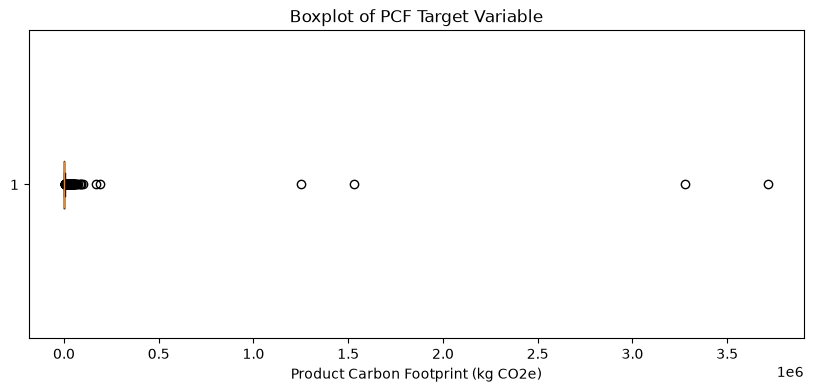

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.boxplot(y, vert=False)
plt.title("Boxplot of PCF Target Variable")
plt.xlabel("Product Carbon Footprint (kg CO2e)")
plt.show()

In [8]:
Q1 = y.quantile(0.25)
Q3 = y.quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Q1          : {Q1:.3f}")
print(f"Q3          : {Q3:.3f}")
print(f"IQR         : {IQR:.3f}")
print(f"Lower Bound : {lower:.3f}")
print(f"Upper Bound : {upper:.3f}")

Q1          : 7.000
Q3          : 1600.000
IQR         : 1593.000
Lower Bound : -2382.500
Upper Bound : 3989.500


In [30]:
print("Median PCF:", y.median())
print("75th Percentile PCF:", y.quantile(0.75))
print("Maximum PCF:", y.max())
print("Minimum PCF:", y.min())
print("Raw skewness:", y.skew())

y_log = np.log1p(y)

Median PCF: 111.1
75th Percentile PCF: 1600.0
Maximum PCF: 3718044.0
Minimum PCF: 0.0004
Raw skewness: 17.63189911896261


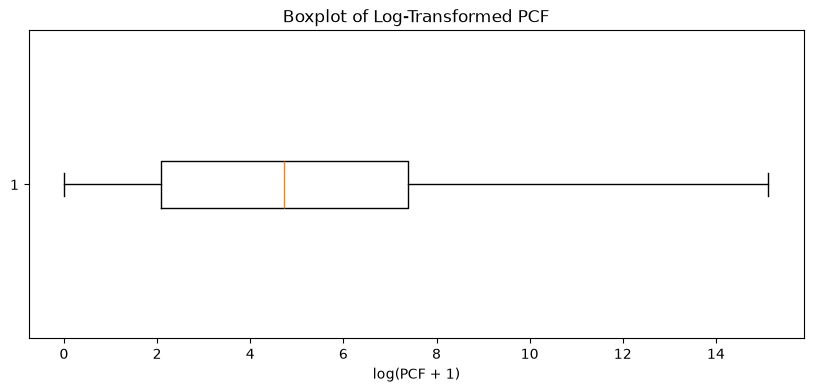

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.boxplot(y_log, vert=False)

plt.title("Boxplot of Log-Transformed PCF")
plt.xlabel("log(PCF + 1)")

plt.show()

In [11]:
# ============================================================
# 6. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state= 42
)

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))

Training rows: 692
Testing rows : 174


In [12]:
# ============================================================
# 7. CREATE SAFE COPIES
# ============================================================

X_train = X_train.copy()
X_test = X_test.copy()

y_train = y_train.copy()
y_test = y_test.copy()

In [13]:
# ============================================================
# 8. COUNTRY → REGION
# ============================================================

country_to_region = {

    # North America
    "USA": "North America",
    "Canada": "North America",

    # Europe
    "Germany": "Europe",
    "Netherlands": "Europe",
    "United Kingdom": "Europe",
    "Switzerland": "Europe",
    "Sweden": "Europe",
    "Finland": "Europe",
    "Italy": "Europe",
    "France": "Europe",
    "Spain": "Europe",
    "Belgium": "Europe",
    "Ireland": "Europe",
    "Luxembourg": "Europe",
    "Lithuania": "Europe",
    "Greece": "Europe",

    # East Asia
    "Japan": "East Asia",
    "Taiwan": "East Asia",
    "South Korea": "East Asia",
    "China": "East Asia",

    # South Asia
    "India": "South Asia",

    # Southeast Asia
    "Malaysia": "Southeast Asia",
    "Indonesia": "Southeast Asia",

    # South America
    "Brazil": "South America",
    "Chile": "South America",
    "Colombia": "South America",

    # Africa
    "South Africa": "Africa",

    # Oceania
    "Australia": "Oceania"
}

X_train["Region"] = X_train[
    "Country"
].map(country_to_region)

X_test["Region"] = X_test[
    "Country"
].map(country_to_region)

X_train["Region"] = (
    X_train["Region"].fillna("Other")
)

X_test["Region"] = (
    X_test["Region"].fillna("Other")
)

X_train.drop(
    columns="Country",
    inplace=True
)

X_test.drop(
    columns="Country",
    inplace=True
)

In [14]:
# ============================================================
# 9. RARE INDUSTRY → OTHER
#    FIT USING TRAINING DATA ONLY
# ============================================================

industry_counts = X_train["Industry"].value_counts()

rare_industries = industry_counts[industry_counts < 10].index
X_train["Industry"] = X_train["Industry"].replace(rare_industries, "Other")

X_test["Industry"] = X_test[
    "Industry"
].replace(
    rare_industries,
    "Other"
)

print(
    "Rare industries grouped:",
    len(rare_industries)
)

Rare industries grouped: 17


In [15]:
# ============================================================
# 10. PCF PROTOCOL → TOP 5 + OTHER
# ============================================================

top_protocols = [
    "ISO",
    "Not reported",
    "GHGP",
    "PAS2050",
    "TRACI 2.1"
]

X_train["PCF_Protocol"] = X_train[
    "PCF_Protocol"
].where(
    X_train["PCF_Protocol"].isin(
        top_protocols
    ),
    "Other"
)

X_test["PCF_Protocol"] = X_test[
    "PCF_Protocol"
].where(
    X_test["PCF_Protocol"].isin(
        top_protocols
    ),
    "Other"
)

In [16]:
# ============================================================
# 11. STAGE-LEVEL CO2e → BINARY
# ============================================================

binary_map = {
    "No": 0,
    "Yes": 1
}

X_train[
    "Stage_Level_CO2e_Available"
] = (
    X_train[
        "Stage_Level_CO2e_Available"
    ]
    .map(binary_map)
    .fillna(0)
)

X_test[
    "Stage_Level_CO2e_Available"
] = (
    X_test[
        "Stage_Level_CO2e_Available"
    ]
    .map(binary_map)
    .fillna(0)
)

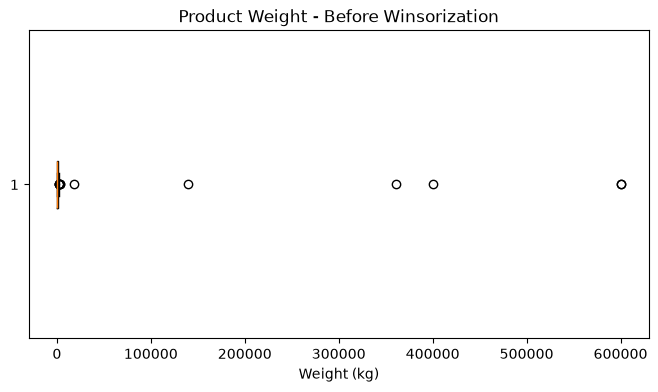

In [17]:
# ============================================================
# 12. PRODUCT WEIGHT — WINSORISATION
#
# Purpose:
# Control extreme Product Weight values using the training
# distribution before applying the logarithmic transformation.
# ============================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.boxplot(X_train["Product_Weight"], vert=False)
plt.title("Product Weight - Before Winsorization")
plt.xlabel("Weight (kg)")
plt.show()

In [18]:
Q1 = X_train["Product_Weight"].quantile(0.25)
Q3 = X_train["Product_Weight"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Lower Bound : {lower:.3f}")
print(f"Upper Bound : {upper:.3f}")

Lower Bound : -1497.500
Upper Bound : 2498.500


In [19]:
outliers = X_train[
    (X_train["Product_Weight"] < lower) |
    (X_train["Product_Weight"] > upper)
]

print("Number of outliers:", len(outliers))

Number of outliers: 12


In [20]:
#Step 4.3: Apply Winsorization
X_train["Product_Weight"] = X_train["Product_Weight"].clip(
    lower=lower,
    upper=upper
)

X_test["Product_Weight"] = X_test["Product_Weight"].clip(
    lower=lower,
    upper=upper
)

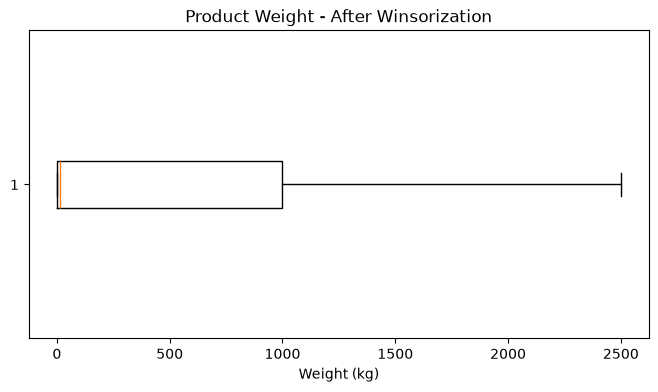

In [21]:
plt.figure(figsize=(8,4))
plt.boxplot(X_train["Product_Weight"], vert=False)
plt.title("Product Weight - After Winsorization")
plt.xlabel("Weight (kg)")
plt.show()

In [22]:
X_train["Product_Weight"].describe()

count     692.000000
mean      363.167180
std       601.179966
min         0.002000
25%         1.000000
50%        15.807694
75%      1000.000000
max      2498.500000
Name: Product_Weight, dtype: float64

In [23]:
# ============================================================
# 15. COMPANY → TARGET ENCODING
#    FIT USING TRAINING DATA ONLY
# ============================================================

te = TargetEncoder(
    cols=["Company"],
    min_samples_leaf=20,
    smoothing=10
)

X_train = te.fit_transform(
    X_train,
    y_train
)

X_test = te.transform(
    X_test
)

In [24]:
# ============================================================
# 16. ONE-HOT ENCODING
# ============================================================

categorical_features = [
    "Industry",
    "PCF_Protocol",
    "Region"
]

encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

encoded_train = encoder.fit_transform(
    X_train[
        categorical_features
    ]
)

encoded_test = encoder.transform(
    X_test[
        categorical_features
    ]
)

encoded_train_df = pd.DataFrame(
    encoded_train,
    columns=encoder.get_feature_names_out(
        categorical_features
    ),
    index=X_train.index
)

encoded_test_df = pd.DataFrame(
    encoded_test,
    columns=encoder.get_feature_names_out(
        categorical_features
    ),
    index=X_test.index
)

X_train = pd.concat(
    [
        X_train.drop(
            columns=categorical_features
        ),
        encoded_train_df
    ],
    axis=1
)

X_test = pd.concat(
    [
        X_test.drop(
            columns=categorical_features
        ),
        encoded_test_df
    ],
    axis=1
)

In [25]:
# ============================================================
# 17. FINAL FEATURE CHECK
# ============================================================

print(
    "Final X_train shape:",
    X_train.shape
)

print(
    "Final X_test shape:",
    X_test.shape
)

print(
    "\nLog Product Weight present:",
    "Log_Product_Weight" in X_train.columns
)

print(
    "Raw Product Weight present:",
    "Product_Weight" in X_train.columns
)

print(
    "Log target used:",
    False
)

print(
    "\nAll features numerical:",
    X_train.select_dtypes(
        exclude="number"
    ).empty
)

print("\nFinal columns:")
print(
    X_train.columns.tolist()
)

Final X_train shape: (692, 34)
Final X_test shape: (174, 34)

Log Product Weight present: False
Raw Product Weight present: True
Log target used: False

All features numerical: True

Final columns:
['Year', 'Company', 'Stage_Level_CO2e_Available', 'Product_Weight', 'Industry_Automobiles', 'Industry_Beverages', 'Industry_Chemicals', 'Industry_Commercial Services & Supplies', 'Industry_Computers & Peripherals', 'Industry_Containers & Packaging', 'Industry_Electrical Equipment', 'Industry_Electronic Equipment, Instruments & Components', 'Industry_Food & Staples Retailing', 'Industry_Food Products', 'Industry_Household Durables', 'Industry_Metals & Mining', 'Industry_Not used for 2015 reporting', 'Industry_Office Electronics', 'Industry_Other', 'Industry_Paper & Forest Products', 'Industry_Software', 'Industry_Textiles, Apparel & Luxury Goods', 'PCF_Protocol_ISO', 'PCF_Protocol_Not reported', 'PCF_Protocol_Other', 'PCF_Protocol_PAS2050', 'PCF_Protocol_TRACI 2.1', 'Region_East Asia', 'Regio

In [26]:
X_train.to_csv("../data/X_train.csv", index=False)
X_test.to_csv("../data/X_test.csv", index=False)
y_train.to_csv("../data/y_train.csv", index=False)
y_test.to_csv("../data/y_test.csv", index=False)